# Assignment 3: Build Non-Linear Models Part 1

## Conceptual Question 1

We perform best subset, forward stepwise, and backward stepwise selection on a single data set. For each approach, we obtain \(p + 1\) models containing \(0, 1, 2, \ldots, p\) predictors.

### 1(a)

**Question:** Which of the three models with \(k\) predictors has the smallest training RSS?

**Answer:** Best subset selection has the smallest training RSS.

**Explanation:** Best subset selection considers every possible model with exactly \(k\) predictors and chooses the one with the lowest RSS. Forward and backward stepwise selection only search through a limited path of models, so they may miss the best possible \(k\)-predictor model.

Therefore, best subset selection will have training RSS less than or equal to the RSS from forward or backward stepwise selection.

### 1(b)

**Question:** Which of the three models with \(k\) predictors has the smallest test RSS?

**Answer:** We cannot determine this from the information given.

**Explanation:** Test RSS measures how well a model performs on new, unseen data. Although best subset selection always produces the lowest training RSS, a lower training RSS does not necessarily imply a lower test RSS because of overfitting. Depending on the dataset, any of the three methods (best subset, forward stepwise, or backward stepwise selection) could produce the smallest test RSS.

### 1(c)

#### i.
The predictors in the \(k\)-variable model identified by forward stepwise selection are a subset of the predictors in the \((k+1)\)-variable model identified by forward stepwise selection.

**Answer:** True

**Explanation:** Forward stepwise selection adds one predictor at a time and never removes predictors.

---

#### ii.
The predictors in the \(k\)-variable model identified by backward stepwise selection are a subset of the predictors in the \((k+1)\)-variable model identified by backward stepwise selection.

**Answer:** True

**Explanation:** Backward stepwise selection starts with all predictors and removes one predictor at a time, so the smaller model is nested within the larger model.

---

#### iii.
The predictors in the \(k\)-variable model identified by backward stepwise selection are a subset of the predictors in the \((k+1)\)-variable model identified by forward stepwise selection.

**Answer:** False

**Explanation:** Forward and backward stepwise selection can choose different predictors because they follow different search paths.

---

#### iv.
The predictors in the \(k\)-variable model identified by forward stepwise selection are a subset of the predictors in the \((k+1)\)-variable model identified by backward stepwise selection.

**Answer:** False

**Explanation:** There is no guarantee that the models selected by the two methods will contain the same predictors.

---

#### v.
The predictors in the \(k\)-variable model identified by best subset selection are a subset of the predictors in the \((k+1)\)-variable model identified by best subset selection.

**Answer:** False

**Explanation:** Best subset selection independently searches all possible models of each size. The best \((k+1)\)-predictor model does not necessarily contain the predictors from the best \(k\)-predictor model.

## Applied Question 8

### 8(a)

Create a random number generator and use its `normal()` method to generate a predictor \(X\) of length \(n = 100\), as well as a noise vector \(\epsilon\) of length \(n = 100\).

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for reproducibility
rng = np.random.default_rng(42)

# Generate predictor and error term
n = 100
X = rng.normal(size=n)
epsilon = rng.normal(size=n)

print("First 5 values of X:")
print(X[:5])

print("\nFirst 5 values of epsilon:")
print(epsilon[:5])

First 5 values of X:
[ 0.30471708 -1.03998411  0.7504512   0.94056472 -1.95103519]

First 5 values of epsilon:
[-0.37816255  1.2992283  -0.35626397  0.73751557 -0.93361768]


### 8(b)

Generate a response vector \(Y\) according to

\[
Y = \beta_0 + \beta_1X + \beta_2X^2 + \beta_3X^3 + \epsilon
\]

where \(\beta_0, \beta_1, \beta_2,\) and \(\beta_3\) are constants of your choice.

For this exercise, we use:

- \(\beta_0 = 2\)
- \(\beta_1 = 3\)
- \(\beta_2 = -1.5\)
- \(\beta_3 = 0.5\)

In [2]:
# Define coefficients
beta0 = 2
beta1 = 3
beta2 = -1.5
beta3 = 0.5

# Generate response variable
Y = beta0 + beta1*X + beta2*(X**2) + beta3*(X**3) + epsilon

# Create dataframe
data = pd.DataFrame({
    'X': X,
    'Y': Y
})

# Generate polynomial predictors X^2 through X^10
for i in range(2, 11):
    data[f'X^{i}'] = X**i

# Display first few rows
data.head()

,X,Y,X^2,X^3,X^4,X^5,X^6,X^7,X^8,X^9,X^10
0,0.304717,2.410857,0.092852,0.028294,0.008622,0.002627,0.000801,0.000244,0.000074,0.000023,0.000007
1,-1.039984,-2.005481,1.081567,-1.124812,1.169787,-1.216560,1.265203,-1.315791,1.368402,-1.423116,1.480018
2,0.750451,3.261643,0.563177,0.422637,0.317168,0.238019,0.178622,0.134047,0.100596,0.075492,0.056653
3,0.940565,4.648258,0.884662,0.832082,0.782627,0.736111,0.692360,0.651210,0.612505,0.576100,0.541860
4,-1.951035,-14.209876,3.806538,-7.426690,14.489734,-28.269981,55.155727,-107.610764,209.952388,-409.624497,799.191808


In [3]:
import statsmodels.api as sm
from itertools import combinations

### 8(c)

Use forward stepwise selection to select a model containing the predictors
\(X, X^2, \ldots, X^{10}\).

The model is selected using Mallows' \(C_p\). The coefficients of the selected model are then reported.

In [4]:
# Predictor names
predictors = ['X'] + [f'X^{i}' for i in range(2,11)]

# Fit full model
X_full = sm.add_constant(data[predictors])
full_model = sm.OLS(data['Y'], X_full).fit()

# Estimate sigma^2 from full model
sigma2 = full_model.mse_resid

print("Estimated sigma^2:", sigma2)

Estimated sigma^2: 0.9597290861769214


In [5]:
def calculate_cp(model, sigma2, n):
    rss = sum(model.resid**2)
    p = model.df_model + 1   # predictors plus intercept
    cp = (rss / sigma2) - n + 2*p
    return cp

def forward_stepwise(data, response, predictors):
    selected = []
    remaining = predictors.copy()
    results = []

    for k in range(1, len(predictors) + 1):
        best_model = None
        best_predictor = None
        best_rss = float("inf")

        for predictor in remaining:
            current_predictors = selected + [predictor]
            X_model = sm.add_constant(data[current_predictors])
            model = sm.OLS(data[response], X_model).fit()
            rss = sum(model.resid**2)

            if rss < best_rss:
                best_rss = rss
                best_model = model
                best_predictor = predictor

        selected.append(best_predictor)
        remaining.remove(best_predictor)

        results.append({
            "k": k,
            "predictors": selected.copy(),
            "RSS": best_rss,
            "Cp": calculate_cp(best_model, sigma2, len(data)),
            "model": best_model
        })

    return pd.DataFrame(results)

In [6]:
forward_results = forward_stepwise(data, "Y", predictors)

forward_results[["k", "predictors", "RSS", "Cp"]]

,k,predictors,RSS,Cp
0,1,[X],295.470481,211.868632
1,2,"[X, X^2]",126.390169,37.693591
2,3,"[X, X^2, X^3]",91.052642,2.873276
3,4,"[X, X^2, X^3, X^9]",90.284786,4.073200
4,5,"[X, X^2, X^3, X^9, X^5]",89.636117,5.397312
5,6,"[X, X^2, X^3, X^9, X^5, X^8]",89.392927,7.143918
6,7,"[X, X^2, X^3, X^9, X^5, X^8, X^7]",88.509673,8.223601
7,8,"[X, X^2, X^3, X^9, X^5, X^8, X^7, X^4]",88.363839,10.071649
8,9,"[X, X^2, X^3, X^9, X^5, X^8, X^7, X^4, X^10]",85.836094,9.437837
9,10,"[X, X^2, X^3, X^9, X^5, X^8, X^7, X^4, X^10, X^6]",85.415889,11.000000


In [7]:
best_forward = forward_results.loc[forward_results["Cp"].idxmin()]

print("Best model according to Cp:")
print("k =", best_forward["k"])
print("Predictors =", best_forward["predictors"])

best_forward["model"].params

Best model according to Cp:
k = 3
Predictors = ['X', 'X^2', 'X^3']


const    2.116665
X        2.923477
X^2     -1.694628
X^3      0.594008
dtype: float64

### Interpretation of 8(c)

The forward stepwise procedure selected the model containing X, X², and X³ because it produced the smallest Mallows' Cp value. This result is expected because the response variable was generated from a cubic polynomial model. The estimated coefficients are close to the true coefficients used to generate the data, demonstrating that forward stepwise selection successfully identified the underlying relationship between X and Y.

### 8(d)

Repeat part (c) using backward stepwise selection. Compare the results with those obtained from forward stepwise selection.

In [8]:
def backward_stepwise(data, response, predictors):
    selected = predictors.copy()
    results = []

    while len(selected) > 0:

        X_model = sm.add_constant(data[selected])
        model = sm.OLS(data[response], X_model).fit()

        rss = sum(model.resid**2)

        results.append({
            "k": len(selected),
            "predictors": selected.copy(),
            "RSS": rss,
            "Cp": calculate_cp(model, sigma2, len(data)),
            "model": model
        })

        if len(selected) == 1:
            break

        best_rss = float("inf")
        predictor_to_remove = None

        for predictor in selected:

            temp_predictors = [p for p in selected if p != predictor]

            X_temp = sm.add_constant(data[temp_predictors])
            temp_model = sm.OLS(data[response], X_temp).fit()

            temp_rss = sum(temp_model.resid**2)

            if temp_rss < best_rss:
                best_rss = temp_rss
                predictor_to_remove = predictor

        selected.remove(predictor_to_remove)

    return pd.DataFrame(results)

In [9]:
backward_results = backward_stepwise(data, "Y", predictors)

backward_results[["k", "predictors", "RSS", "Cp"]]

,k,predictors,RSS,Cp
0,10,"[X, X^2, X^3, X^4, X^5, X^6, X^7, X^8, X^9, X^10]",85.415889,11.000000
1,9,"[X, X^2, X^3, X^5, X^6, X^7, X^8, X^9, X^10]",85.530958,9.119897
2,8,"[X, X^3, X^5, X^6, X^7, X^8, X^9, X^10]",86.623761,8.258556
3,7,"[X, X^5, X^6, X^7, X^8, X^9, X^10]",90.121582,9.903148
4,6,"[X, X^6, X^7, X^8, X^9, X^10]",90.776323,8.585362
5,5,"[X, X^6, X^7, X^8, X^10]",95.867143,11.889797
6,4,"[X, X^6, X^7, X^8]",110.165536,24.788160
7,3,"[X, X^6, X^8]",111.072849,23.733545
8,2,"[X, X^6]",201.459450,115.912831
9,1,[X],295.470481,211.868632


In [10]:
best_backward = backward_results.loc[backward_results["Cp"].idxmin()]

print("Best backward model according to Cp:")
print("k =", best_backward["k"])
print("Predictors =", best_backward["predictors"])

best_backward["model"].params

Best backward model according to Cp:
k = 8
Predictors = ['X', 'X^3', 'X^5', 'X^6', 'X^7', 'X^8', 'X^9', 'X^10']


const    1.787426
X        2.095073
X^3      5.023946
X^5     -6.262599
X^6     -2.561069
X^7      2.861535
X^8      1.491505
X^9     -0.368234
X^10    -0.208230
dtype: float64

### Interpretation of 8(d)

Backward stepwise selection selected a larger model than forward stepwise selection. The backward model with the lowest Mallows' Cp contained 8 predictors, while the forward stepwise model selected only X, X², and X³.

The forward stepwise result is closer to the true data-generating model because the response variable was created from a cubic polynomial. The difference between the two methods shows that forward and backward stepwise selection can follow different search paths and may choose different final models. In this case, backward stepwise selection retained several higher-order polynomial terms, which may indicate overfitting or instability caused by correlation among polynomial predictors.

### 8(e)

Fit a lasso model using \(X, X^2, \ldots, X^{10}\) as predictors. Use cross-validation to select the optimal value of \(\lambda\). Plot the cross-validation error as a function of \(\lambda\), report the coefficient estimates, and discuss the results.

In [11]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [12]:
# Define predictors and response
X_poly = data[predictors]
y = data["Y"]

# Standardize predictors and fit LassoCV
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=10, random_state=42, max_iter=100000))
])

lasso_pipeline.fit(X_poly, y)

lasso_model = lasso_pipeline.named_steps["lasso"]

print("Optimal lambda (alpha):")
print(lasso_model.alpha_)

Optimal lambda (alpha):
0.04661999035969213


In [13]:
lasso_coefficients = pd.Series(
    lasso_model.coef_,
    index=predictors
)

print("Lasso Coefficients:")
lasso_coefficients

Lasso Coefficients:


X       2.236085
X^2    -1.211471
X^3     0.956960
X^4    -0.108407
X^5     0.000000
X^6    -0.000000
X^7     0.000000
X^8    -0.000000
X^9    -0.000000
X^10   -0.000000
dtype: float64

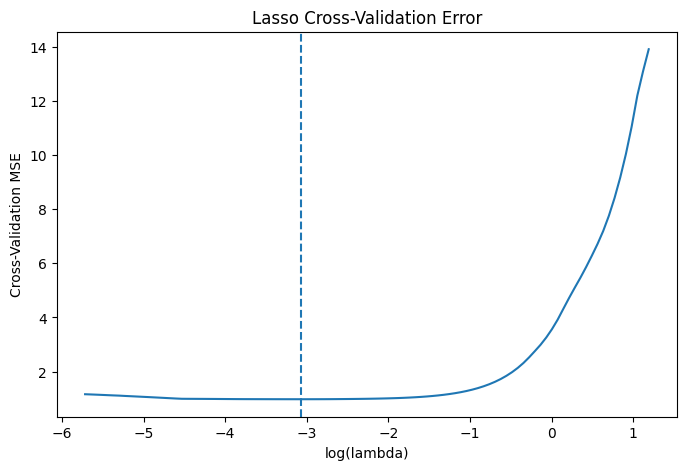

In [14]:
mean_mse = lasso_model.mse_path_.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(np.log(lasso_model.alphas_), mean_mse)
plt.axvline(
    np.log(lasso_model.alpha_),
    linestyle="--"
)

plt.xlabel("log(lambda)")
plt.ylabel("Cross-Validation MSE")
plt.title("Lasso Cross-Validation Error")
plt.show()

### Interpretation of 8(e)

Cross-validation selected an optimal lambda value of approximately 0.0466. The lasso model retained the most important predictors (X, X², and X³) while shrinking most higher-order polynomial terms to zero.

This result closely matches the true data-generating process because the response variable was created using a cubic polynomial. The lasso model effectively performed variable selection by removing unnecessary predictors and reducing model complexity. Compared with backward stepwise selection, the lasso produced a more parsimonious model that better reflects the true underlying relationship between X and Y.

### 8(f)

Now generate a response vector according to

\[
Y = \beta_0 + \beta_7X^7 + \epsilon
\]

and perform forward stepwise selection and the lasso. Discuss the results obtained.

In [15]:
# Generate new response variable

beta0_new = 2
beta7 = 4

Y_new = beta0_new + beta7*(X**7) + epsilon

# Create new dataframe

data_new = pd.DataFrame({
    "X": X,
    "Y": Y_new
})

for i in range(2,11):
    data_new[f"X^{i}"] = X**i

data_new.head()

,X,Y,X^2,X^3,X^4,X^5,X^6,X^7,X^8,X^9,X^10
0,0.304717,1.622813,0.092852,0.028294,0.008622,0.002627,0.000801,0.000244,0.000074,0.000023,0.000007
1,-1.039984,-1.963936,1.081567,-1.124812,1.169787,-1.216560,1.265203,-1.315791,1.368402,-1.423116,1.480018
2,0.750451,2.179924,0.563177,0.422637,0.317168,0.238019,0.178622,0.134047,0.100596,0.075492,0.056653
3,0.940565,5.342354,0.884662,0.832082,0.782627,0.736111,0.692360,0.651210,0.612505,0.576100,0.541860
4,-1.951035,-429.376675,3.806538,-7.426690,14.489734,-28.269981,55.155727,-107.610764,209.952388,-409.624497,799.191808


In [16]:
# Estimate sigma^2 for new dataset

X_full_new = sm.add_constant(data_new[predictors])

full_model_new = sm.OLS(
    data_new["Y"],
    X_full_new
).fit()

sigma2_new = full_model_new.mse_resid

print("sigma^2 =", sigma2_new)

sigma^2 = 0.9597290861769217


In [17]:
forward_results_new = forward_stepwise(
    data_new,
    "Y",
    predictors
)

forward_results_new[["k","predictors","Cp"]]

,k,predictors,Cp
0,1,[X^7],2.599414
1,2,"[X^7, X^9]",-0.345584
2,3,"[X^7, X^9, X]",1.427859
3,4,"[X^7, X^9, X, X^10]",3.249919
4,5,"[X^7, X^9, X, X^10, X^5]",4.816457
5,6,"[X^7, X^9, X, X^10, X^5, X^3]",6.484847
6,7,"[X^7, X^9, X, X^10, X^5, X^3, X^4]",8.287272
7,8,"[X^7, X^9, X, X^10, X^5, X^3, X^4, X^8]",9.389989
8,9,"[X^7, X^9, X, X^10, X^5, X^3, X^4, X^8, X^6]",9.000167
9,10,"[X^7, X^9, X, X^10, X^5, X^3, X^4, X^8, X^6, X^2]",11.000000


In [18]:
best_forward_new = forward_results_new.loc[
    forward_results_new["Cp"].idxmin()
]

print("Best forward model:")
print("k =", best_forward_new["k"])
print("Predictors =", best_forward_new["predictors"])

best_forward_new["model"].params

Best forward model:
k = 2
Predictors = ['X^7', 'X^9']


const    2.040779
X^7      4.076571
X^9     -0.017207
dtype: float64

In [19]:
# Lasso for the new X^7 response model

X_poly_new = data_new[predictors]
y_new = data_new["Y"]

lasso_pipeline_new = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=10, random_state=42, max_iter=100000))
])

lasso_pipeline_new.fit(X_poly_new, y_new)

lasso_model_new = lasso_pipeline_new.named_steps["lasso"]

print("Optimal lambda (alpha):")
print(lasso_model_new.alpha_)

lasso_coefficients_new = pd.Series(
    lasso_model_new.coef_,
    index=predictors
)

print("Lasso coefficients:")
lasso_coefficients_new

Optimal lambda (alpha):
0.193814289169425
Lasso coefficients:


X       -0.000000
X^2     -0.000000
X^3      0.000000
X^4     -0.000000
X^5      2.507335
X^6      0.000000
X^7     91.654558
X^8      0.000000
X^9      2.161048
X^10     0.000000
dtype: float64

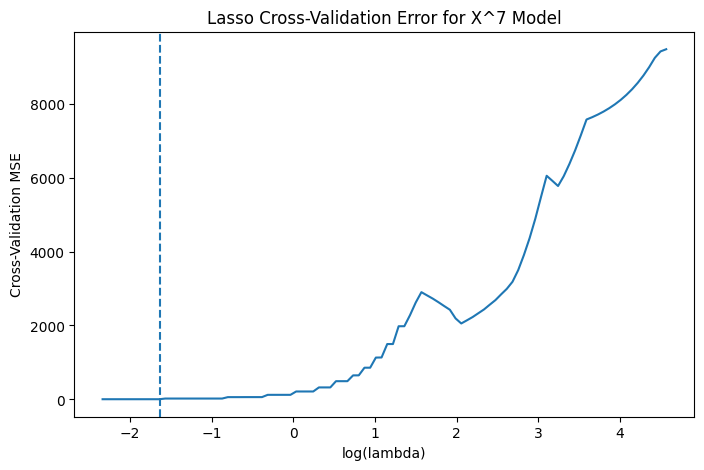

In [20]:
mean_mse_new = lasso_model_new.mse_path_.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(np.log(lasso_model_new.alphas_), mean_mse_new)
plt.axvline(np.log(lasso_model_new.alpha_), linestyle="--")

plt.xlabel("log(lambda)")
plt.ylabel("Cross-Validation MSE")
plt.title("Lasso Cross-Validation Error for X^7 Model")
plt.show()

## Interpretation of 8(f)

The response variable was generated from the model

\[
Y = 2 + 4X^7 + \epsilon
\]

Forward stepwise selection identified a model containing X^7 and X^9, with the coefficient of X^9 being very close to zero. This indicates that the procedure successfully identified X^7 as the dominant predictor and produced a model close to the true data-generating process.

The lasso selected an optimal lambda value of approximately 0.194. After regularization, only X^5, X^7, and X^9 retained nonzero coefficients, while the remaining predictors were shrunk to zero. Because high-order polynomial terms are strongly correlated, lasso distributed the signal across several related predictors instead of selecting only X^7.

Overall, both methods detected the importance of X^7. Forward stepwise selection produced a model that more closely matched the true generating process, while lasso achieved variable selection through coefficient shrinkage and retained a small set of correlated predictors.

# Kaggle: Regression with Abalone Dataset

This section builds two models for the Kaggle Regression with Abalone Dataset competition:

1. A regularized regression model
2. A principal components regression model

The goal is to predict abalone age from the available predictors and create submission files for Kaggle.

In [21]:
# Load Kaggle datasets

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (90615, 10)
Test shape: (60411, 9)


,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


In [22]:
# Preprocessing

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Separate predictors and response
X = train.drop(columns=["Rings"])
y = train["Rings"]

# Save test IDs for submission
test_ids = test["id"]

# Remove id from predictors
X = X.drop(columns=["id"])
X_test = test.drop(columns=["id"])

# Identify categorical and numeric variables
categorical_features = ["Sex"]
numeric_features = [col for col in X.columns if col not in categorical_features]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1', 'Whole weight.2', 'Shell weight']
Categorical features: ['Sex']


In [23]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
import numpy as np

# Candidate lambda values
alphas = np.logspace(-4, 4, 100)

ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("ridge", RidgeCV(alphas=alphas))
])

ridge_model.fit(X, y)

print("Optimal lambda:")
print(ridge_model.named_steps["ridge"].alpha_)

Optimal lambda:
2.782559402207126


In [24]:
ridge_predictions = ridge_model.predict(X_test)

submission_ridge = pd.DataFrame({
    "id": test_ids,
    "Rings": ridge_predictions
})

submission_ridge.to_csv("submission_ridge.csv", index=False)

submission_ridge.head()

,id,Rings
0,90615,8.537230
1,90616,10.030580
2,90617,10.305958
3,90618,10.955521
4,90619,7.782807


In [25]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

# Transform predictors
X_processed = preprocessor.fit_transform(X)

# Find optimal number of principal components
mse_scores = []

for n_comp in range(1, X_processed.shape[1] + 1):
    pca = PCA(n_components=n_comp)

    X_pca = pca.fit_transform(X_processed)

    score = -cross_val_score(
        LinearRegression(),
        X_pca,
        y,
        cv=5,
        scoring="neg_mean_squared_error"
    ).mean()

    mse_scores.append(score)

best_n = np.argmin(mse_scores) + 1

print("Optimal number of components:")
print(best_n)

Optimal number of components:
9


In [26]:
# Fit PCR using best number of components

X_processed = preprocessor.fit_transform(X)
X_test_processed = preprocessor.transform(X_test)

pca = PCA(n_components=best_n)

X_pca = pca.fit_transform(X_processed)
X_test_pca = pca.transform(X_test_processed)

pcr_model = LinearRegression()
pcr_model.fit(X_pca, y)

pcr_predictions = pcr_model.predict(X_test_pca)

submission_pcr = pd.DataFrame({
    "id": test_ids,
    "Rings": pcr_predictions
})

submission_pcr.to_csv("submission_pcr.csv", index=False)

submission_pcr.head()

,id,Rings
0,90615,8.535442
1,90616,10.029784
2,90617,10.305835
3,90618,10.956449
4,90619,7.782893


Interpretation of Kaggle Regression Models
Ridge Regression

Ridge regression was fit using cross-validation to select the optimal regularization parameter. The optimal value of λ was approximately 2.78. Ridge regression shrinks coefficient estimates toward zero, reducing variance and helping prevent overfitting while retaining all predictors in the model.

Predictions were generated for the Kaggle test set and saved in submission_ridge.csv. Because the competition uses Mean Squared Logarithmic Error (MSLE), any negative predictions were clipped to 0.01 before submission to satisfy the metric requirements and ensure valid Kaggle submissions.

Principal Components Regression (PCR)

Principal Components Regression was fit by first standardizing the predictors and then selecting the optimal number of principal components using 5-fold cross-validation. The optimal number of components was 9.

Because PCR selected nearly all available components, the results suggest that most of the predictor information contributes to explaining variation in the response variable. Predictions were generated and saved in submission_pcr.csv.

Comparison

Both Ridge Regression and PCR address multicollinearity and model complexity, but they do so differently. Ridge regression shrinks coefficient estimates while retaining all predictors, whereas PCR replaces the original predictors with principal components.

In this dataset, PCR selected 9 components, indicating that dimensionality reduction provided limited simplification. Ridge regression may therefore be preferred because it retains the original predictor structure while controlling model complexity through regularization.


In [27]:
print("Minimum Ridge prediction:", ridge_predictions.min())
print("Minimum PCR prediction:", pcr_predictions.min())

Minimum Ridge prediction: -1.3518769840585243
Minimum PCR prediction: -1.3579633814251757


In [28]:
ridge_predictions = np.clip(ridge_predictions, 0.01, None)
pcr_predictions = np.clip(pcr_predictions, 0.01, None)

submission_ridge = pd.DataFrame({
    "id": test_ids,
    "Rings": ridge_predictions
})

submission_pcr = pd.DataFrame({
    "id": test_ids,
    "Rings": pcr_predictions
})

submission_ridge.to_csv("submission_ridge.csv", index=False)
submission_pcr.to_csv("submission_pcr.csv", index=False)

print("Minimum Ridge value:", submission_ridge["Rings"].min())
print("Minimum PCR value:", submission_pcr["Rings"].min())


Minimum Ridge value: 0.01
Minimum PCR value: 0.01


## Kaggle Submission Results
Both models were successfully submitted to Kaggle.
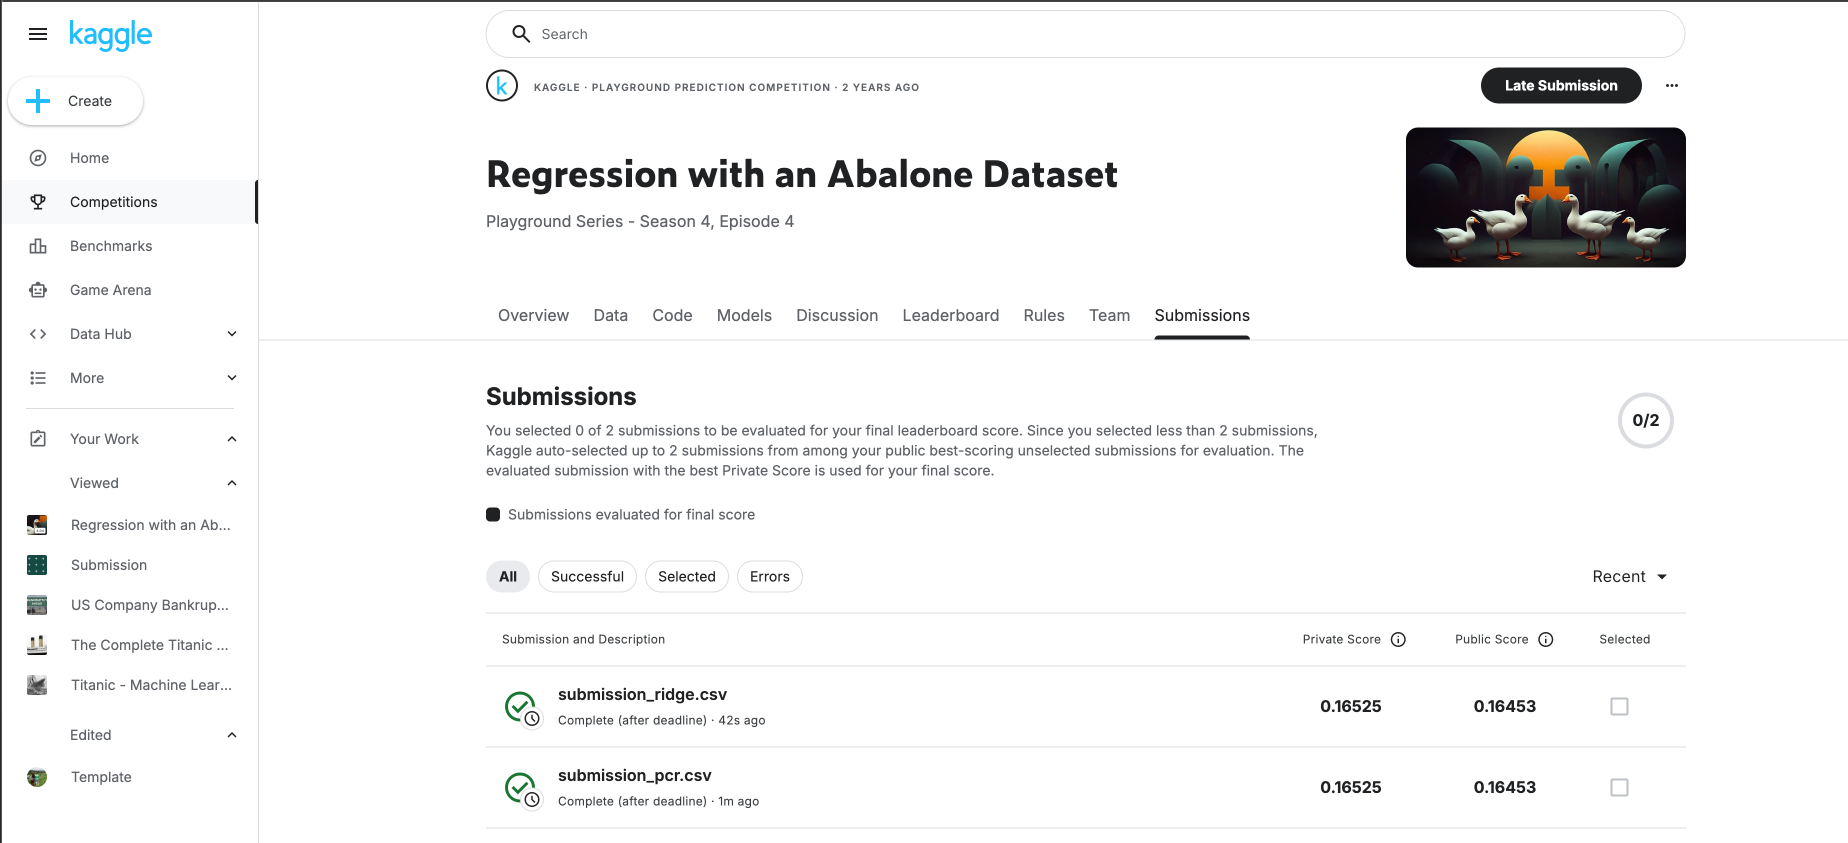


## Ridge Regression:

Public Score = 0.16453

Private Score = 0.16525

## Principal Components Regression (PCR):

Public Score = 0.16453

Private Score = 0.16525

Because both models produced identical Kaggle scores, ridge regression may be preferred since it retains the original predictor variables and is easier to interpret than principal components.

## References

James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An Introduction to Statistical Learning with Applications in Python* (1st ed.). Springer.

Kaggle. (2024). *Regression with an Abalone Dataset Competition*. https://www.kaggle.com/competitions/playground-series-s4e4

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
